In [1]:
import jax
import jax.nn as jnn
import jax.numpy as jnp
import jax.random as jrandom
from jaxtyping import Array, PRNGKeyArray
from typing import Tuple, Callable

import equinox as eqx
from equinox._module import field
from equinox._misc import default_floating_dtype
import optax

import torch
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import math
from typing import Callable, Optional

import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# Read the training data

In [2]:
# load entire dataset into pandas
df = pd.read_csv('./data/preprocessed.csv', index_col=0,)
df.head()

,Q,P,TAMAX,TAMIN
1979-10-01,0.260515,0.0,26.0,3.0
1979-10-02,0.243525,0.0,29.0,3.0
1979-10-03,0.229366,0.0,28.0,3.0
1979-10-04,0.215208,0.0,28.0,4.0
1979-10-05,0.215208,0.0,29.0,5.0


# Data preprocessing

## Data normalization

In [3]:
scaler, df_norm = {}, df.copy()

for varn in df.columns:
    # scaler_v = StandardScaler()
    scaler_v = MinMaxScaler()
    df_norm[varn] = scaler_v.fit_transform(df[[varn]].values)
    scaler[varn] = scaler_v

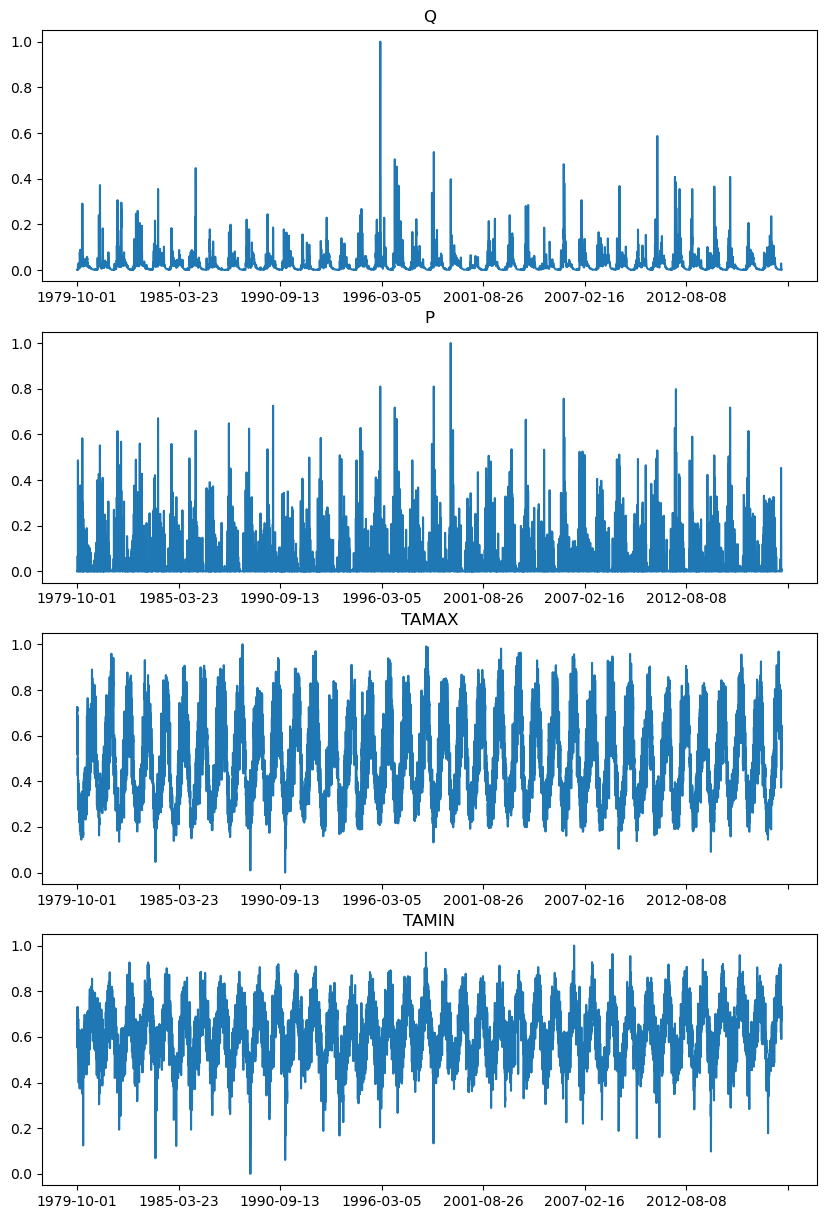

In [4]:
varns = df_norm.keys().to_list()
fig, axes = plt.subplots(4, 1, figsize=(10,15))
for i,ax in enumerate(axes):
    varn = varns[i]
    df_norm[varn].plot(ax=ax)
    ax.set(title=varn)

## Split the data into training and test sets

In [5]:
train_start = '1979-10-01' # starts 1 year later due to padding in figure
train_end = '2010-09-30'

test_start = '2010-10-01' # starts 1 year later due to padding in figure
test_end = '2018-09-30'


In [6]:
# divide dataset in training and test set
df_norm_train = df_norm.loc[train_start:train_end].copy()
df_norm_test = df_norm.loc[test_start:test_end].copy()

# print fraction the test set is of all the used data
print('Test set fraction: ', len(df_norm_test) / (len(df_norm_train) + len(df_norm_test)))

Test set fraction:  0.18422190201729108


# Rainfall-Runoff modeling

## Configuration

In [207]:
# Model output variable
target   = 'Q'

# Model input feature
# features = list(df_norm.columns.difference([target]))
# features = ['P']
mass_features = ['P']
aux_features = ['TAMAX', 'TAMIN']

# DL model configuration and training settings
sequence_length = 365
batch_size = 64
learning_rate = 0.001
hidden_size = 64
epochs = 150

# Random keys
data_key, model_key = jrandom.split(jrandom.PRNGKey(1024), 2)


## Create a pytorch custom dataset

In [8]:
class TimeSeriesDataset(Dataset):
    def __init__(self, dataframe, target, mass_features, aux_features, sequence_length=5):

        # save which are the features and target data and sequence length
        self.mass_features = mass_features
        self.aux_features = aux_features
        self.target = target
        self.sequence_length = sequence_length

        # load data from dataframe into tensor
        y = torch.tensor(dataframe[self.target].values).float()
        xm = torch.tensor(dataframe[self.mass_features].values).float()
        xa = torch.tensor(dataframe[self.aux_features].values).float()

        # remove padding from data and save data in class
        self.y = y[sequence_length:]
        self.xm = xm[sequence_length:,:]
        self.xa = xa[sequence_length:,:]

        # make extra dataseries for padding
        self.yPadding = y[:sequence_length*2]
        self.xmPadding = xm[:sequence_length*2,:]
        self.xaPadding = xa[:sequence_length*2,:]
        # self.sequence_length = sequence_length


    def __len__(self):
        # return length shape
        return self.xm.shape[0]


    def __getitem__(self, i): 
        # select data from the dataset without padding and return data
        if i > self.sequence_length:
            xmr = self.xm[i-self.sequence_length:i,:]
            xar = self.xa[i-self.sequence_length:i,:]
            yr = self.y[i-1]

            # return xmr, xar, yr
            return torch.cat([xmr, xar], dim=1), yr
          
        # select from the padding dataset and return data
        else:
            xmr = self.xmPadding[i:i+self.sequence_length,:]
            xar = self.xaPadding[i:i+self.sequence_length,:]
            yr = self.yPadding[i+self.sequence_length - 1]

            # return xmr, xar, yr
            return torch.cat([xmr, xar], dim=1), yr


In [173]:
# make train and test dataset
train_dataset = TimeSeriesDataset(df_norm_train,
                                  target=[target],
                                  mass_features=mass_features,
                                  aux_features=aux_features,
                                  sequence_length=sequence_length)
test_dataset = TimeSeriesDataset(df_norm_test,
                                target=[target],
                                mass_features=mass_features,
                                aux_features=aux_features,
                                sequence_length=sequence_length)

# load dataset in DataLoader
train_loader = DataLoader(train_dataset, 
                          batch_size=batch_size, 
                          shuffle=True)
test_loader = DataLoader(test_dataset, 
                         batch_size=batch_size, 
                         shuffle=False)
train_eval_loader = DataLoader(train_dataset, 
                               batch_size=batch_size,  
                               shuffle=False)


## Define a MC-LSTM model using JAX

In [100]:
class Gate(eqx.Module):
    fc: eqx.nn.Linear
    in_features: int
    out_features: int
    
    def __init__(
        self,
        in_features: int,
        out_features: int,
        key: PRNGKeyArray,
    ):
        self.fc = eqx.nn.Linear(in_features, out_features, key=key)
        self.in_features = in_features
        self.out_features = out_features
    
    def __call__(self, x):
        return jnn.sigmoid(self.fc(x))


class NormalizedGate(eqx.Module):
    fc: eqx.nn.Linear
    activation: Callable
    in_features: int
    out_shape: int
    normalizer: str
    
    def __init__(
        self,
        in_features: int,
        out_shape: Tuple[int, int],
        normalizer: str,
        key: PRNGKeyArray,
    ):
        out_features = out_shape[0]*out_shape[1]
        self.fc = eqx.nn.Linear(in_features, out_features, key=key)
        self.in_features = in_features
        self.out_shape = out_shape
        
        self.normalizer = normalizer
        if normalizer == "normalized_sigmoid":
            self.activation = jnn.sigmoid
        elif normalizer == "normalized_relu":
            self.activation = jnn.relu
        else:
            raise ValueError(
                f"Unknown normalizer {normalizer}. Must be one of {'normalized_sigmoid', 'normalized_relu'}")
    
    def __call__(self, x):
        h = self.activation(self.fc(x).reshape(self.out_shape))
        normalized_h = jnp.linalg.norm(h, ord=1, axis=0, keepdims=True) 
        normalized_h = h / normalized_h
        return normalized_h



In [178]:
class MCLSTMCell(eqx.Module):
    input_gate: NormalizedGate
    output_gate: Gate
    redistribution: NormalizedGate
    mass_input_size: int
    aux_input_size: int
    hidden_size: int

    def __init__(
        self,
        mass_input_size: int,
        aux_input_size: int,
        hidden_size: int,
        *,
        key: PRNGKeyArray,
    ):
        gate_inputs = aux_input_size + hidden_size + mass_input_size
        
        key1, key2, key3 = jrandom.split(key, 3)

        self.output_gate = Gate(in_features=gate_inputs, out_features=hidden_size, key=key1)
        self.input_gate = NormalizedGate(in_features=gate_inputs, out_shape=(hidden_size, mass_input_size), 
                                         normalizer='normalized_sigmoid', key=key2)
        self.redistribution = NormalizedGate(in_features=gate_inputs, out_shape=(hidden_size, hidden_size), 
                                             normalizer='normalized_sigmoid', key=key3)
        self.mass_input_size = mass_input_size
        self.aux_input_size = aux_input_size
        self.hidden_size = hidden_size

    def __call__(self, xm, xa, c, *, key=None):
        features = jnp.concat([xm, xa, c / (jnp.linalg.norm(c, ord=1) + 1e-5)])
        
        # Compute gate activations
        i = self.input_gate(features)  # shape: (hidden_size, mass_input_size)
        r = self.redistribution(features)  # shape: (hidden_size, hidden_size)
        o = self.output_gate(features)  # shape: (hidden_size,)
        
        # Distribute incoming mass over the cell states
        # m_in = jnp.expand_dims(xm,0) @ i # shape: (1, hidden_size)
        m_in = i @ jnp.expand_dims(xm,-1)
        m_in = m_in.flatten()  # shape: (hidden_size,)
        
        # Reshuffle the mass in the cell states using the redistribution matrix
        # m_sys = jnp.expand_dims(c,0) @ r # shape: (1, hidden_size)
        m_sys = r @ jnp.expand_dims(c,-1)
        m_sys = m_sys.flatten()  # shape: (hidden_size,)
        
        # Compute the new mass states
        m_new = m_in + m_sys  # shape: (hidden_size,)
        
        # Return the outgoing mass and subtract this value from the cell states
        h = o * m_new
        c = (1 - o) * m_new
        return h, c


class MCLSTM(eqx.Module):
    cell: MCLSTMCell
    mass_input_size: int
    aux_input_size: int
    hidden_size: int

    def __init__(
        self,
        mass_input_size: int,
        aux_input_size: int,
        hidden_size: int,
        *,
        key: PRNGKeyArray
    ):
        ckey, lkey = jrandom.split(key)
        self.cell = MCLSTMCell(mass_input_size, aux_input_size, hidden_size, key=key)
        self.mass_input_size = mass_input_size
        self.aux_input_size = aux_input_size
        self.hidden_size = hidden_size

    def calculate_hidden(self, x):
        xm, xa = x[...,:self.mass_input_size], x[...,self.mass_input_size:self.mass_input_size+self.aux_input_size]
        
        init_state = (jnp.zeros(self.cell.hidden_size),
                      jnp.zeros(self.cell.hidden_size))

        def f(carry, inp):
            h_tprev, c_tprev = carry
            xm_t, xa_t = inp
            h_t,c_t = self.cell(xm_t, xa_t, c_tprev)
            return (h_t,c_t), (h_t,c_t,xm_t)
        states_t, states_all = jax.lax.scan(f, init_state, [xm, xa])
        
        return states_t, states_all
    
    def __call__(self, x):
        states_t, states_all = self.calculate_hidden(x)
        h_t, c_t = states_t   # shape: (hidden_size,), (hidden_size,)
        return jnp.array([h_t[1:].sum()])  # shape: (1,)
        # return ht[..., 1:].sum(dim=-1, keepdim=True) 
        # return self.linear(ht)



In [157]:
# TODO: Add a separate trash cells


In [181]:
# check if the features and targets are made accordingly with the right shapes
# and sizes(trust us, they are)
x, y = next(iter(train_loader))
print('Features shape:', x.shape)
# print('Aux features shape:', xa.shape)
print('Target shape:', y.shape)

model = MCLSTM(mass_input_size=len(mass_features), aux_input_size=len(aux_features), hidden_size=hidden_size, key=model_key)
model


Features shape: torch.Size([64, 365, 3])
Target shape: torch.Size([64, 1])


MCLSTM(
  cell=MCLSTMCell(
    input_gate=NormalizedGate(
      fc=Linear(
        weight=f32[64,67],
        bias=f32[64],
        in_features=67,
        out_features=64,
        use_bias=True
      ),
      activation=<wrapped function sigmoid>,
      in_features=67,
      out_shape=(64, 1),
      normalizer='normalized_sigmoid'
    ),
    output_gate=Gate(
      fc=Linear(
        weight=f32[64,67],
        bias=f32[64],
        in_features=67,
        out_features=64,
        use_bias=True
      ),
      in_features=67,
      out_features=64
    ),
    redistribution=NormalizedGate(
      fc=Linear(
        weight=f32[4096,67],
        bias=f32[4096],
        in_features=67,
        out_features=4096,
        use_bias=True
      ),
      activation=<wrapped function sigmoid>,
      in_features=67,
      out_shape=(64, 64),
      normalizer='normalized_sigmoid'
    ),
    mass_input_size=1,
    aux_input_size=2,
    hidden_size=64
  ),
  mass_input_size=1,
  aux_input_size=2,
  hid

In [159]:
# h=jnp.array([-1,2,3,4,5,-9])
# h / jnp.linalg.norm(h, ord=1, axis=-1, keepdims=True) 

# h=torch.tensor([-1.,2.,3.,4.,5.,-9.])
# torch.nn.functional.normalize(h, p=1, dim=-1)

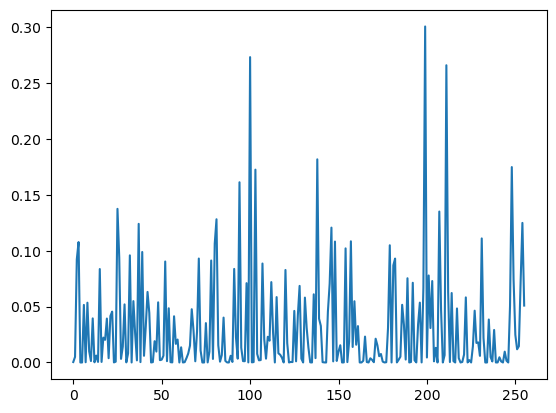

In [160]:
# xm_jax, xa_jax = jnp.array(xm), jnp.array(xa)
y1 = jax.vmap(model)(jnp.array(x))
plt.plot(y1)


## Train the DL model

In [179]:
# Define a loss function
def loss_mse(model, x, y):
    # jax.debug.print("x = {x}", x=x.shape)
    pred_y = jax.vmap(model)(x)
    return jnp.mean((y - pred_y) ** 2)


In [213]:
@eqx.filter_jit
def make_step(model, opt_state, x, y,loss_func, optim):
    loss_value, grads = eqx.filter_value_and_grad(loss_func)(model, x, y)
    updates, opt_state = optim.update(grads, opt_state, model)
    # updates, opt_state = optim.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss_value

def train_each_step(model, trainloader, loss_func, optim, opt_state):
    train_loss, k = 0, 0
    num_batches = len(trainloader)
    for i, (x, y) in enumerate(trainloader):
        x, y = jnp.array(x), jnp.array(y)
        model, opt_state, train_loss_each = make_step(model, opt_state, x, y, loss_func, optim)
        k += 1
        train_loss += train_loss_each
    train_loss /= num_batches
    print(f"Training loss: {train_loss}")
    return model, opt_state, train_loss

def evaluate(model, testloader, loss_func):
    test_loss, k = 0, 0
    num_batches = len(testloader)
    loss_func = eqx.filter_jit(loss_func)
    for i, (x, y) in enumerate(testloader):
        x, y = jnp.array(x), jnp.array(y)
        test_loss_each = loss_func(model, x, y)
        k += 1
        test_loss += test_loss_each
    
    # print(f'Test loss: {test_loss}')
    test_loss /= k
    print(f'Test loss: {test_loss}')
    return test_loss

def train(model, nsteps, loss_func, optim, trainloader, testloader):
    opt_state = optim.init(eqx.filter(model, eqx.is_array))

    loss_train_set, loss_test_set = [], []
    for step in range(nsteps):
        print('\n')
        print(f'Epoch {step}\n-----')
        # Update the model on the training data
        model, opt_state, loss_value_train = train_each_step(
            model, trainloader, loss_func, optim, opt_state)

        # Evaluate the model on the test data
        if testloader is not None:
            loss_value_test = evaluate(model, testloader, loss_func)
            loss_train_set.append(loss_value_train)
            loss_test_set.append(loss_value_test)
        else:
            loss_train_set.append(loss_value_train)
    
    loss_train_set = jnp.array(loss_train_set)
    loss_test_set = jnp.array(loss_test_set)
    
    return model, loss_train_set, loss_test_set

def predict(data_loader, model):
    # initiaze output data
    y_pred_set = []

    # iterate through data from data loader and make prediction
    for i, (x,y) in enumerate(data_loader):
        x, y = jnp.array(x), jnp.array(y)
        y_pred = jax.vmap(model)(x)
        y_pred_set.append(y_pred)
    
    return jnp.concatenate(y_pred_set, 0)

def predict_h_c(data_loader, model):
    # initiaze output data
    y_pred_set = []
    s_pred_set = []
    other_pred_set = []

    # iterate through data from data loader and make prediction
    for i, (x,y) in enumerate(data_loader):
        x, y = jnp.array(x), jnp.array(y)
        states_t, _ = jax.vmap(model.calculate_hidden)(x)
        h, c = states_t
        y_pred = h[:,1:].sum(axis=1)
        s_pred = c.sum(axis=1)
        other_pred = h[:,0]
        y_pred_set.append(y_pred)
        s_pred_set.append(s_pred)
        other_pred_set.append(other_pred)
    
    y_pred_set = jnp.concatenate(y_pred_set, 0)
    s_pred_set = jnp.concatenate(s_pred_set, 0)
    other_pred_set = jnp.concatenate(other_pred_set, 0)
    
    return y_pred_set, s_pred_set, other_pred_set

# def predict(data_loader, model):
#     # initiaze output data
#     y_pred_set = []
#     y_set = []
    
#     test_loss, k = 0, 0
#     num_batches = len(data_loader)

#     # iterate through data from data loader and make prediction
#     for i, (x,y) in enumerate(data_loader):
#         x, y = jnp.array(x), jnp.array(y)
#         y_pred = jax.vmap(model)(x)
#         y_pred_set.append(y_pred)
#         y_set.append(y)
        
#         test_loss_each = loss_mse(model, x, y)
#         test_loss += test_loss_each
#         # y_pred_set = jnp.concatenate((y_pred_set, y_pred), 0)
#     y_pred_set = jnp.concatenate(y_pred_set, 0)
#     y_set = jnp.concatenate(y_set, 0)
    
#     print(test_loss / num_batches)
#     print(jnp.mean((y_pred_set - y_set)**2))
#     return y_pred_set, y_set

# def predict(data_loader, model):
#     # initiaze output data
#     y_pred_set = []
#     yc_pred_set = []
#     ht_pred_set = []
#     ct_pred_set = []

#     # iterate through data from data loader and make prediction
#     for i, (x,y) in enumerate(data_loader):
#         x, y = jnp.array(x), jnp.array(y)
#         y_pred, yc_pred, ht_pred, ct_pred = jax.vmap(model.output_all)(x)
#         # y_pred_set.append(ht_pred[:,-1])
#         y_pred_set.append(y_pred)
#         yc_pred_set.append(yc_pred)
#         ht_pred_set.append(ht_pred)
#         ct_pred_set.append(ct_pred)
#         # y_pred_set = jnp.concatenate((y_pred_set, y_pred), 0)
    
#     return jnp.concatenate(y_pred_set, 0), \
#            jnp.concatenate(yc_pred_set, 0), \
#            jnp.concatenate(ht_pred_set, 0), \
#            jnp.concatenate(ct_pred_set, 0)


In [208]:
evaluate(model, test_loader, loss_mse)

Test loss: 0.0018667642725631595


Array(0.00186676, dtype=float32)

In [209]:
# test_model(model, test_loader, loss_mse)
optim = optax.adamw(learning_rate)
model, loss_train, loss_test = train(model, epochs, loss_mse, optim, train_loader, test_loader)




Epoch 0
-----
Training loss: 0.0015471375081688166
Test loss: 0.001377131324261427


Epoch 1
-----
Training loss: 0.0011980280978605151
Test loss: 0.0010668389732018113


Epoch 2
-----
Training loss: 0.0009575096191838384
Test loss: 0.0008581190486438572


Epoch 3
-----
Training loss: 0.0008076587691903114
Test loss: 0.0007299476419575512


Epoch 4
-----
Training loss: 0.000708101550117135
Test loss: 0.0006430359208025038


Epoch 5
-----
Training loss: 0.0006364567670971155
Test loss: 0.0005917632370255888


Epoch 6
-----
Training loss: 0.0006022861343808472
Test loss: 0.0005686705117113888


Epoch 7
-----
Training loss: 0.0005880657117813826
Test loss: 0.0005602632299996912


Epoch 8
-----
Training loss: 0.0005798867205157876
Test loss: 0.0005560235003940761


Epoch 9
-----
Training loss: 0.0005760033964179456
Test loss: 0.0005529144546017051


Epoch 10
-----
Training loss: 0.0005736869643442333
Test loss: 0.0005502395797520876


Epoch 11
-----
Training loss: 0.0005706122610718012
T

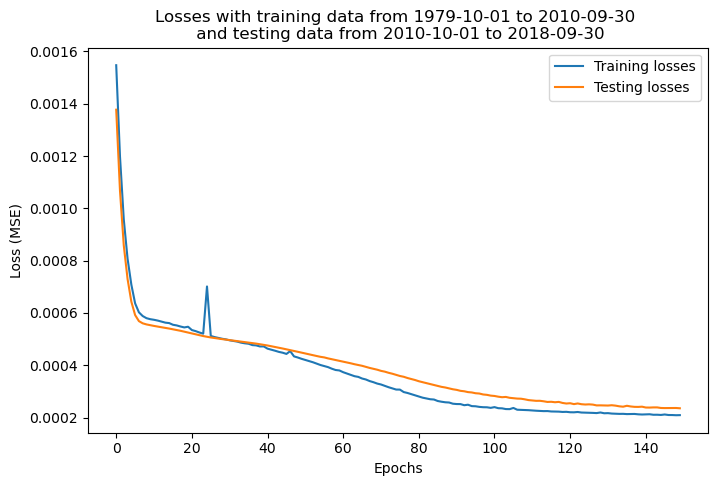

In [210]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(loss_train, label='Training losses')
ax.plot(loss_test, label='Testing losses')
ax.set(title=f'Losses with training data from {train_start} to {train_end} \n and testing data from {test_start} to {test_end}',
       ylabel='Loss (MSE)', xlabel='Epochs')
ax.legend(loc='upper right');


## Prediction

In [215]:
# predict data with model
# y_pred_train = predict(train_eval_loader, model)
# y_pred_test = predict(test_loader, model)
# y_pred_train, y_train = predict(train_eval_loader, model)
# y_pred_test, y_test = predict(test_loader, model)
y_pred_train, s_pred_train, other_pred_train = predict_h_c(train_eval_loader, model)
y_pred_test, s_pred_test, other_pred_test = predict_h_c(test_loader, model)

# make placeholder for model output data
y_pred_col = 'LSTM model discharge prediction'

# load data in dataframe
df_train_out = pd.DataFrame(index=df_norm_train.index[sequence_length:],
                            data={target:df_norm_train[target][sequence_length:].values,
                                  'storage':s_pred_train.flatten(),
                                  'other fluxes': other_pred_train.flatten(),
                                  y_pred_col:y_pred_train.flatten()})

df_test_out = pd.DataFrame(index=df_norm_test.index[sequence_length:],
                        data={target:df_norm_test[target][sequence_length:].values,
                              'storage':s_pred_test.flatten(),
                              'other fluxes': other_pred_test.flatten(),
                              y_pred_col:y_pred_test.flatten()})

# # de-normalize data
# for col in df_train_out.columns:
#     df_train_out[col] = scaler[target].inverse_transform(df_train_out[[col]].values)

# for col in df_test_out.columns:
#     df_test_out[col] = scaler[target].inverse_transform(df_test_out[[col]].values)

# calculate RMSE for both datasets
# MSE_test = ((y_test.flatten() - df_test_out[y_pred_col].values) ** 2).mean()
# MSE_train = ((y_train.flatten()- df_train_out[y_pred_col].values) ** 2).mean()
MSE_test = ((df_test_out[target].values - df_test_out[y_pred_col].values) ** 2).mean()
MSE_train = ((df_train_out[target].values - df_train_out[y_pred_col].values) ** 2).mean()
CC_test  = jnp.corrcoef(df_test_out[target].values, df_test_out[y_pred_col].values)[0,1]
CC_train = jnp.corrcoef(df_train_out[target].values, df_train_out[y_pred_col].values)[0,1]


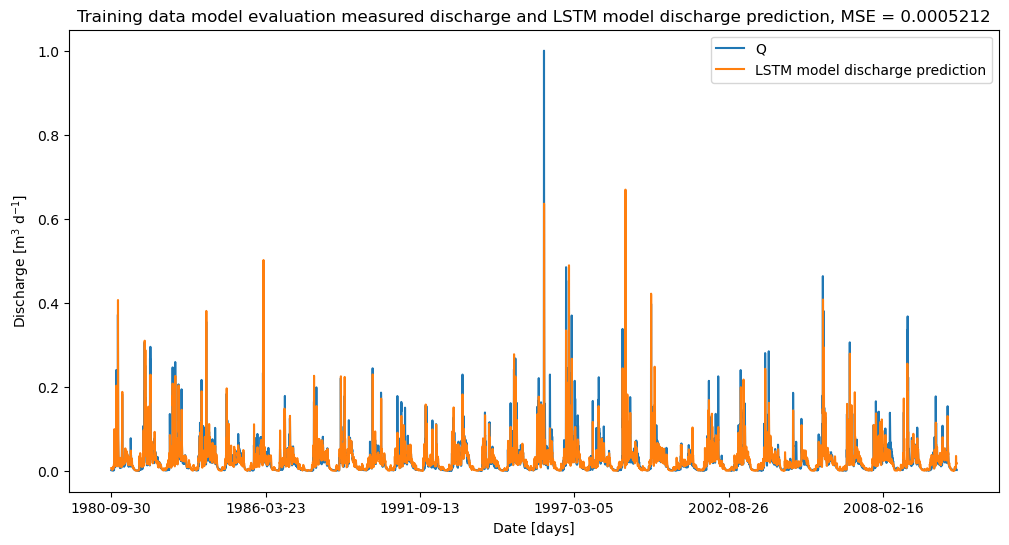

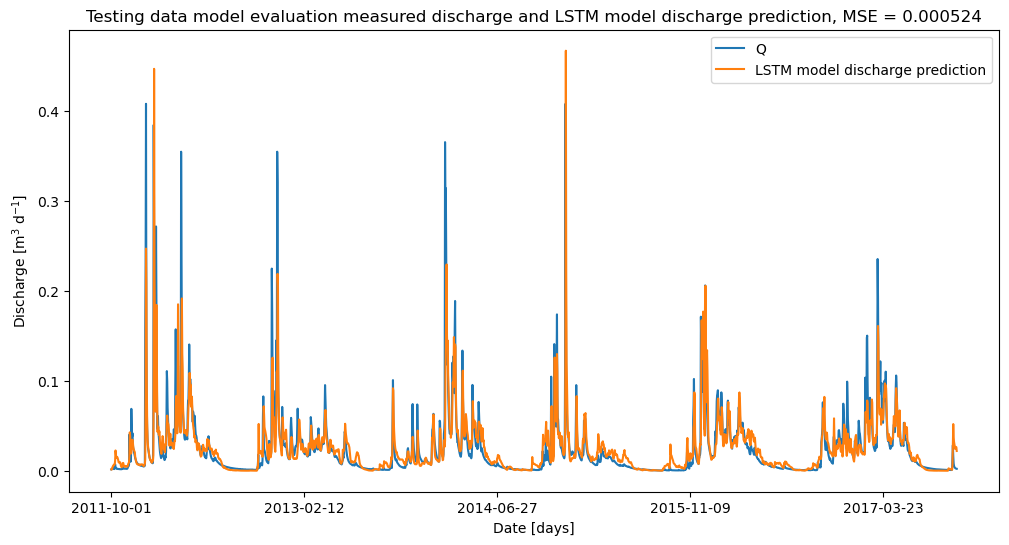

In [217]:
# plot
fig,ax = plt.subplots(figsize=(12,6))
df_train_out[[target, y_pred_col]].plot(ax=ax)
ax.set_ylabel('Discharge [m$^3$ d$^{-1}$]');
ax.set_xlabel('Date [days]');
ax.set_title(f'Training data model evaluation measured discharge and LSTM model discharge prediction, MSE = {MSE_train:.4}');
fig.show()

# plot
fig,ax = plt.subplots(figsize=(12,6))
df_test_out[[target, y_pred_col]].plot(ax=ax)
ax.set_ylabel('Discharge [m$^3$ d$^{-1}$]');
ax.set_xlabel('Date [days]');
ax.set_title(f'Testing data model evaluation measured discharge and LSTM model discharge prediction, MSE = {MSE_test:.4}');
fig.show()


In [ ]:
# Plot the storage
fig,ax = plt.subplots(figsize=(12,6))
df_train_out[['storage']].plot(ax=ax)
axt = ax.twinx()
df_train_out[['other fluxes']].plot(ax=axt, color='green', alpha=0.4)
ax.set_ylabel('');
ax.set_xlabel('Date [days]');
ax.set_title(f'Training data model evaluation measured discharge and LSTM model discharge prediction, MSE = {MSE_train:.4}');
fig.show()

# plot
fig,ax = plt.subplots(figsize=(12,6))
df_test_out[['storage']].plot(ax=ax)
axt = ax.twinx()
df_test_out[['other fluxes']].plot(ax=axt, color='green', alpha=0.4)
ax.set_ylabel('');
ax.set_xlabel('Date [days]');
ax.set_title(f'Testing data model evaluation measured discharge and LSTM model discharge prediction, MSE = {MSE_test:.4}');
fig.show()


## Check the mass balance


In [205]:
def check_mass_balance(ct, xm1_t, h1_t):
    total_storage = ct.sum()
    total_in = xm1_t.sum()
    total_out = h1_t.sum()
    # print(total_storage)
    # print(total_in- total_out)
    assert jnp.isclose(total_storage, total_in - total_out)

In [187]:
x, y = next(iter(test_loader))
states_t, states_all = jax.vmap(model.calculate_hidden)(jnp.array(x))
h, c, xm = states_all


In [206]:
ib, it = 40, 60
check_mass_balance(c[ib,it-1,:], xm[ib,:it,:], h[ib,:it,:])

0.026848558
0.026848793
